# Veriyi Tanıma ve Görselleştirme:

/tmp/ipykernel_2631/373060505.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette='viridis')


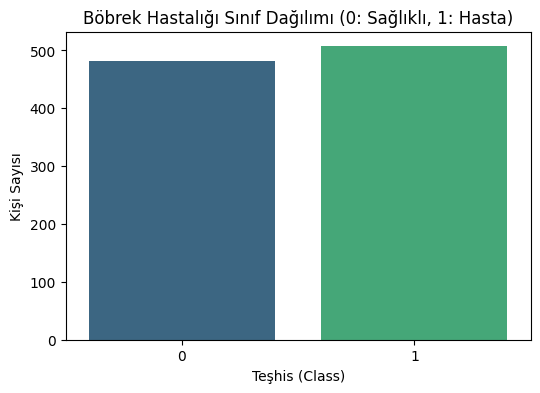

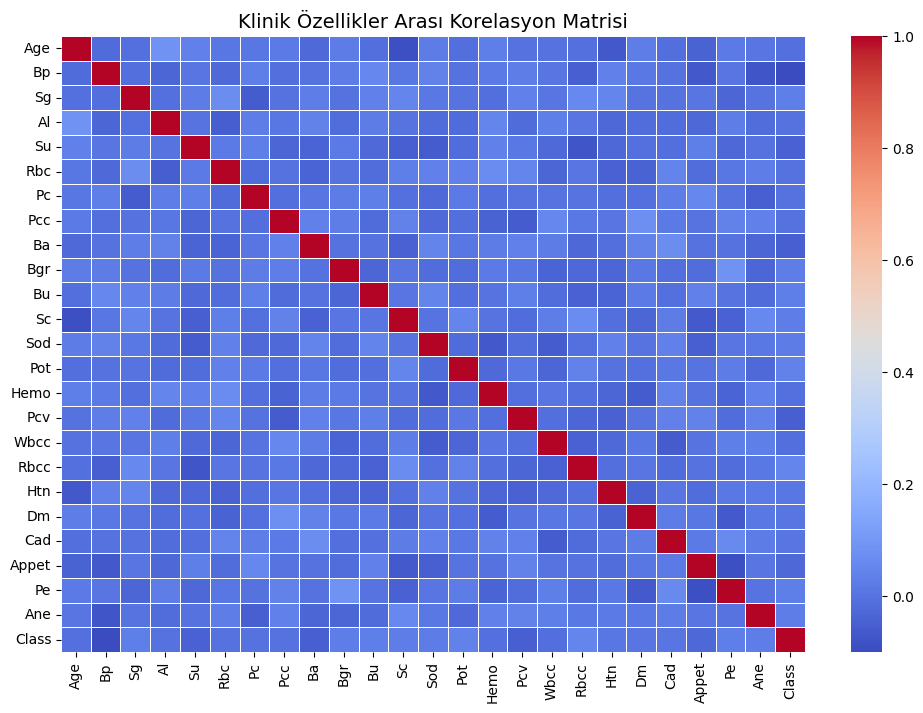

Hastalık (Class) ile en yüksek korelasyona sahip ilk 5 özellik:
Rbcc    0.046776
Pot     0.039335
Bu      0.031633
Pe      0.031133
Sg      0.030238
Name: Class, dtype: float64


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Veriyi Yükleme
df = pd.read_csv("BD-KDD Dataset.csv")

# Analize katkısı olmadığı için 'Sl. No.' (Seri Numarası) kolonunu çıkarıyoruz
df = df.drop('Sl. No.', axis=1)

# 2. Sınıf Dağılımı Görselleştirmesi
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df, palette='viridis')
plt.title('Böbrek Hastalığı Sınıf Dağılımı (0: Sağlıklı, 1: Hasta)')
plt.xlabel('Teşhis (Class)')
plt.ylabel('Kişi Sayısı')
plt.show()

# 3. Korelasyon Matrisi Görselleştirmesi
# Özelliklerin birbiriyle ve hastalıkla olan ilişkisini haritalandırıyoruz
plt.figure(figsize=(10, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Klinik Özellikler Arası Korelasyon Matrisi', fontsize=14)
plt.show()

# 4. Hastalıkla en çok ilişkili (korele) olan ilk 5 özelliği
print("Hastalık (Class) ile en yüksek korelasyona sahip ilk 5 özellik:")
print(corr_matrix['Class'].sort_values(ascending=False)[1:6])

# Model Kurulumu ve Metriklerin Hesaplanması (Random Forest):

--- MODEL SONUÇLARI ---

Doğruluk Oranı (Accuracy): %50.51

Detaylı Sınıflandırma Raporu (F-measure, Sensitivity/Recall vb.):
              precision    recall  f1-score   support

Sağlıklı (0)       0.51      0.50      0.51       100
   Hasta (1)       0.50      0.51      0.51        98

    accuracy                           0.51       198
   macro avg       0.51      0.51      0.51       198
weighted avg       0.51      0.51      0.51       198



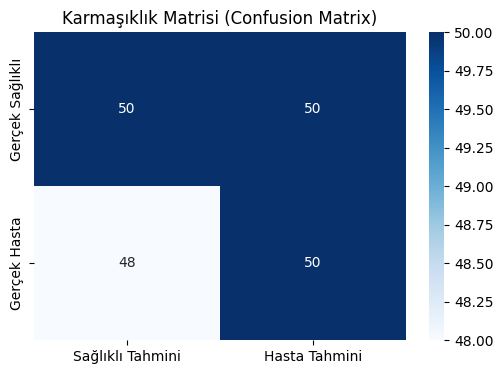

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Veriyi Bağımsız Değişkenler (X) ve Hedef Değişken (y) Olarak Ayırma
X = df.drop('Class', axis=1)
y = df['Class']

# 2. Eğitim ve Test Seti Bölünmesi (%80 Eğitim, %20 Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Random Forest Modelinin Kurulması ve Eğitilmesi
# n_estimators: Ağaç sayısı. random_state: Sonuçların her çalıştırdığında aynı çıkması için.
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 4. Test Verisi Üzerinde Tahmin Yapılması
y_pred = rf_model.predict(X_test)

# 5. Sonuçların ve Metriklerin Değerlendirilmesi
accuracy = accuracy_score(y_test, y_pred)
print(f"--- MODEL SONUÇLARI ---\n")
print(f"Doğruluk Oranı (Accuracy): %{accuracy * 100:.2f}\n")

print("Detaylı Sınıflandırma Raporu (F-measure, Sensitivity/Recall vb.):")
# Sınıf 0: Sağlıklı, Sınıf 1: Böbrek Hastası
print(classification_report(y_test, y_pred, target_names=['Sağlıklı (0)', 'Hasta (1)']))

# 6. Karmaşıklık Matrisi (Confusion Matrix) Görselleştirmesi
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sağlıklı Tahmini', 'Hasta Tahmini'],
            yticklabels=['Gerçek Sağlıklı', 'Gerçek Hasta'])
plt.title('Karmaşıklık Matrisi (Confusion Matrix)')
plt.show()

# Roc eğrisi, Özellik Önemi , KDE Plot:

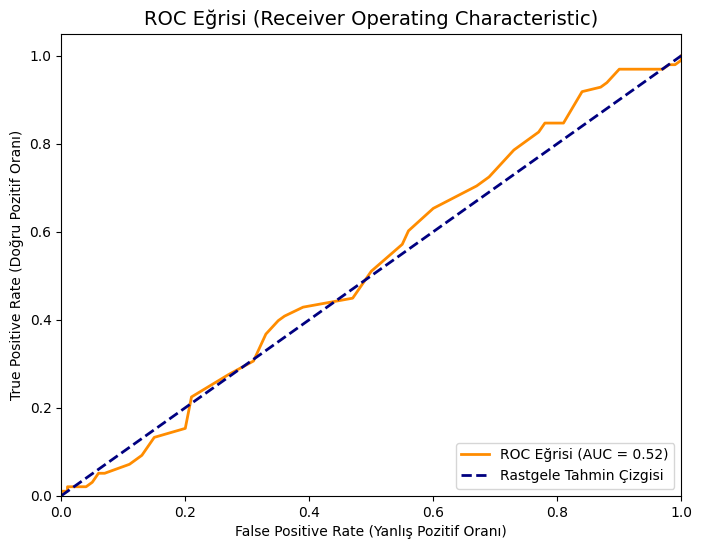

/tmp/ipykernel_2631/2516847841.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_df, palette='magma')


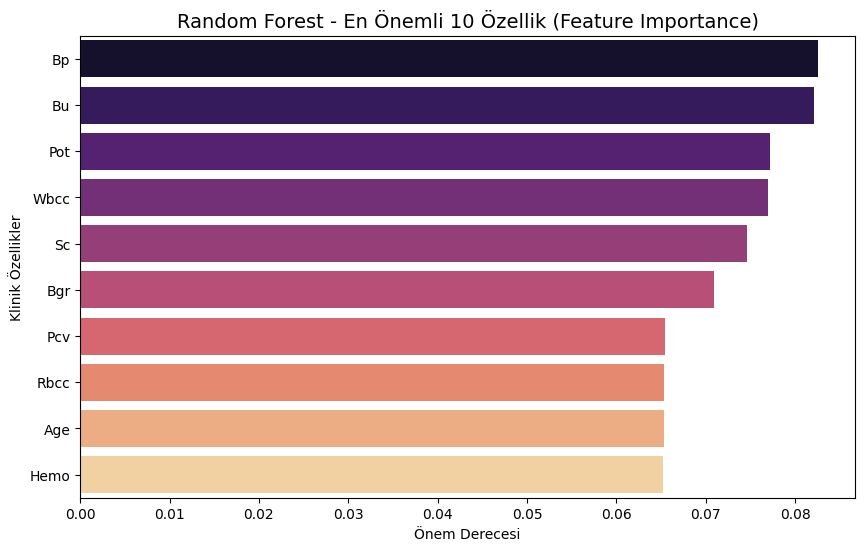

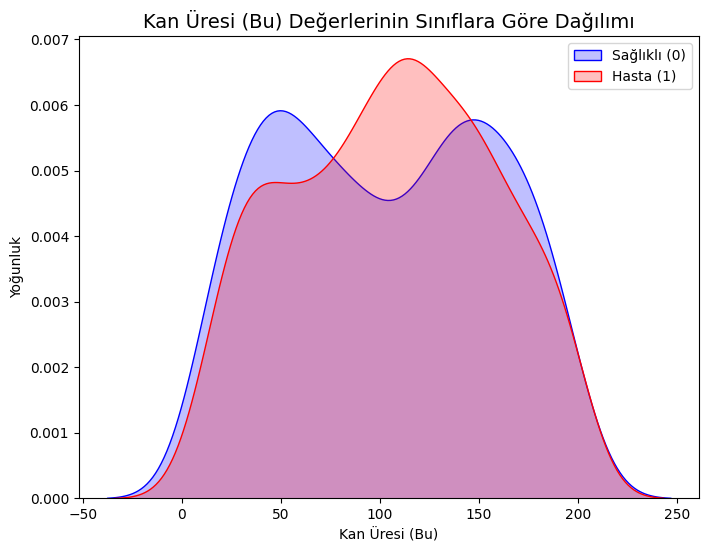

In [6]:
from sklearn.metrics import roc_curve, auc

# 1. ROC EĞRİSİ (ROC Curve)
# Sınıflandırma olasılıklarını hesaplıyoruz (Sadece 1 sınıfının olasılıkları)
y_prob = rf_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Eğrisi (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Rastgele Tahmin Çizgisi')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Yanlış Pozitif Oranı)')
plt.ylabel('True Positive Rate (Doğru Pozitif Oranı)')
plt.title('ROC Eğrisi (Receiver Operating Characteristic)', fontsize=14)
plt.legend(loc="lower right")
plt.show()

# 2. ÖZELLİK ÖNEMİ (Feature Importance)
# Modelin hangi değişkenlere ne kadar ağırlık verdiği bulunur
importances = rf_model.feature_importances_
feature_names = X.columns
feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False).head(10) # Sadece en önemli 10'unu alıyoruz

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_df, palette='magma')
plt.title('Random Forest - En Önemli 10 Özellik (Feature Importance)', fontsize=14)
plt.xlabel('Önem Derecesi')
plt.ylabel('Klinik Özellikler')
plt.show()

# 3. ÖRTÜŞEN DAĞILIM GRAFİĞİ (KDE Plot)
plt.figure(figsize=(8, 6))
sns.kdeplot(data=df[df['Class'] == 0], x='Bu', label='Sağlıklı (0)', fill=True, color='blue')
sns.kdeplot(data=df[df['Class'] == 1], x='Bu', label='Hasta (1)', fill=True, color='red')
plt.title('Kan Üresi (Bu) Değerlerinin Sınıflara Göre Dağılımı', fontsize=14)
plt.xlabel('Kan Üresi (Bu)')
plt.ylabel('Yoğunluk')
plt.legend()
plt.show()